## Importações

In [2]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TCNModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.missing_values import fill_missing_values
from darts.utils.timeseries_generation import datetime_attribute_timeseries

from urllib import request

warnings.filterwarnings("ignore")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Download e Exportação do Dataset

In [2]:
url_dados = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/intercambio_nacional_ho/"
arquivo_dados = "INTERCAMBIO_NACIONAL_"
historico_dados = ["2022", "2023", "2024", "2025"]

for ano in historico_dados:
    request.urlretrieve(url_dados+arquivo_dados+ano+".csv", arquivo_dados+ano+".csv")

dataframe_final = pd.DataFrame()
for ano in historico_dados:
    dataframe = pd.read_csv(arquivo_dados+ano+".csv", sep=";", encoding="utf-8")
    dataframe_final = pd.concat([dataframe_final, dataframe], ignore_index=True)

dataframe_final.to_csv(f"INTERCAMBIO_NACIONAL_{historico_dados[0]}-{historico_dados[-1]}.csv", sep=";", index=False, encoding="utf-8")


## Carregamento de dados

In [25]:
dados = pd.read_csv("INTERCAMBIO_NACIONAL_2024.csv", sep=";", encoding="utf-8")

dados.head()

,din_instante,id_subsistema_origem,nom_subsistema_origem,id_subsistema_destino,nom_subsistema_destino,val_intercambiomwmed
0,2024-01-01 00:00:00,N,NORTE,NE,NORDESTE,2699.626
1,2024-01-01 00:00:00,N,NORTE,SE,SUDESTE,-3760.924
2,2024-01-01 00:00:00,NE,NORDESTE,SE,SUDESTE,-2794.053
3,2024-01-01 00:00:00,SE,SUDESTE,S,SUL,-4762.211
4,2024-01-01 01:00:00,N,NORTE,NE,NORDESTE,2594.904


## Simplificação de dados

In [26]:
# Excluir colunas "id_subsistema_origem" e "id_subsistema_destino"
dataframe = dados.drop(columns=["id_subsistema_origem", "id_subsistema_destino"], errors="ignore")

# Substituir valores de duas colunas SUDESTE -> SUDESTE/CENTRO-OESTE
dataframe['nom_subsistema_origem'] = dataframe['nom_subsistema_origem'].replace({'SUDESTE': 'SUDESTE/CENTRO-OESTE'})
dataframe['nom_subsistema_destino'] = dataframe['nom_subsistema_destino'].replace({'SUDESTE': 'SUDESTE/CENTRO-OESTE'})

# Converter coluna de timestamp para datetime
#dataframe['din_instante'] = pd.to_datetime(dataframe['din_instante'])

dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35136 entries, 0 to 35135
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   din_instante            35136 non-null  object 
 1   nom_subsistema_origem   35136 non-null  object 
 2   nom_subsistema_destino  35136 non-null  object 
 3   val_intercambiomwmed    35136 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB


## Seleção de um subsistema

In [27]:
# Dataframes separados com base em "nom_subsistema_origem" e "nom_subsistema_destino"
dataframe_n_ne = dataframe[(dataframe['nom_subsistema_origem'] == 'NORTE') & (dataframe['nom_subsistema_destino'] == 'NORDESTE')].reset_index(drop=True)

dataframe_n_ne.head()

,din_instante,nom_subsistema_origem,nom_subsistema_destino,val_intercambiomwmed
0,2024-01-01 00:00:00,NORTE,NORDESTE,2699.626
1,2024-01-01 01:00:00,NORTE,NORDESTE,2594.904
2,2024-01-01 02:00:00,NORTE,NORDESTE,2579.920
3,2024-01-01 03:00:00,NORTE,NORDESTE,2447.814
4,2024-01-01 04:00:00,NORTE,NORDESTE,2365.706


## Covariáveis

In [28]:
# Aplicar features de calendário
# ts_df_features = add_calendar_features(dataframe_n_ne.set_index('din_instante')[['val_intercambiomwmed']].rename(columns={'val_intercambiomwmed': 'MW'}), holidays.country_holidays("BR")["2023-01-01":"2025-08-31"])

# ts_df_features.head()

## Carrega dataset

In [35]:
# Define dataset
ts = TimeSeries.from_dataframe(dataframe_n_ne, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="H")

# Create training and validation sets:
train, val = ts.split_after(pd.Timestamp("2024-08-30 23:00:00"))

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

<Axes: xlabel='din_instante'>

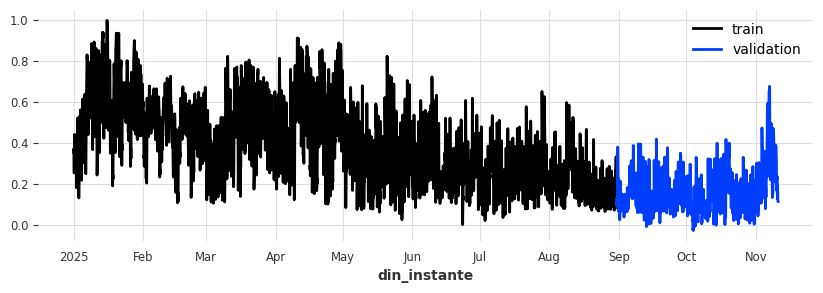

In [30]:
plt.figure(figsize=(10, 3))
train_scaled.plot(label="train")
val_scaled.plot(label="validation")

## Construir modelo

In [36]:
model_name = "TCN_energia"
my_model = TCNModel(
    input_chunk_length=2160, # 3 meses 
    output_chunk_length=168,  # 1 semana
    n_epochs=20,
    dropout=0.2,
    dilation_base=2,
    weight_norm=True,
    kernel_size=5,
    num_filters=8,
    nr_epochs_val_period=1,
    random_state=0,
    save_checkpoints=True,
    model_name=model_name,
    force_reset=True,
    **generate_torch_kwargs(),
)

## Treinar modelo

In [37]:
my_model.fit(
    series=train_scaled,
    val_series=val_scaled,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 5.5 K  | train
-------------------------------------------------------------
5.5 K     Trainable params
0         Non-trainable params
5.5 K     Total params
0.022     Total estimated model params size (MB)
107       Modules in train mode
0         Modules in eval mode


Training: 0it [00:00, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## Carregar modelo

In [ ]:
my_model = TCNModel.load_from_checkpoint(model_name=model_name, best=True)

## Backtest

In [ ]:
backtest = my_model.historical_forecasts(
    series=ts_scaled,
    start=val_scaled.start_time(),
    forecast_horizon=6,
    retrain=False,
    verbose=True,
)

In [ ]:
ts_scaled.plot(label="actual")
backtest.plot(label="backtest (H=6)")